In this part, we import the libraries needed for building and training the model

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In this part, we load the KMNIST dataset from the local system.

We have 4 types of data:
* **Train images**
* **Train labels**
* **Test images**
* **Test labels**

We obtain the dimensions (shapes) of these 4 data types.

```python
data.shape
```

In [7]:
train_imgs = np.load("kmnist-train-imgs.npz")["arr_0"]
train_labels = np.load("kmnist-train-labels.npz")["arr_0"]
test_imgs = np.load("kmnist-test-imgs.npz")["arr_0"]
test_labels = np.load("kmnist-test-labels.npz")["arr_0"]

print("Train images shape:", train_imgs.shape)
print("Train labels shape:", train_labels.shape)
# 
print("Test images shape:", test_imgs.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In this part, we display some sample images to better understand the dataset.

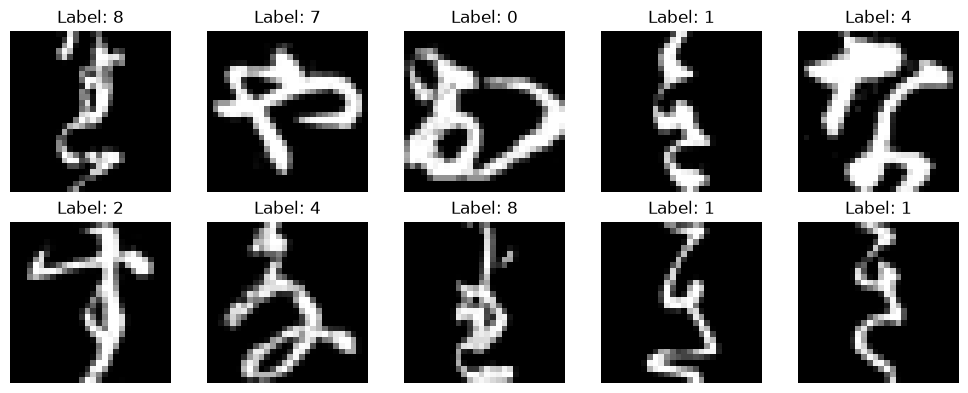

In [8]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_imgs[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In this part, we prepare the data for training using batches.

In [ ]:

class KMNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

full_train_dataset = KMNISTDataset(train_imgs, train_labels)
test_dataset = KMNISTDataset(test_imgs, test_labels)

# train/validation split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In this part, we define the CNN architecture.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            # input (batch,1, 28,28)and padding add 1 pixel around image
            nn.Conv2d(1, 16, kernel_size=3, padding=1), # in_channels, out_channels, kernel_size, padding
            nn.ReLU(),
            nn.MaxPool2d(2), # (16, 14, 14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # in_channels, out_channels, kernel_size, padding
            nn.ReLU(),
            nn.MaxPool2d(2) # (32, 7, 7)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In this part, we train the model on the training data.

In [12]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def evaluate(loader, model):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total
    return avg_loss, acc


In [13]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(val_loader, model)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

Epoch [1/5] Train Loss: 0.4141 Val Loss: 0.1758 Val Acc: 94.75%
Epoch [2/5] Train Loss: 0.1329 Val Loss: 0.1119 Val Acc: 96.64%
Epoch [3/5] Train Loss: 0.0804 Val Loss: 0.0879 Val Acc: 97.44%
Epoch [4/5] Train Loss: 0.0551 Val Loss: 0.0787 Val Acc: 97.97%
Epoch [5/5] Train Loss: 0.0379 Val Loss: 0.0753 Val Acc: 98.05%


In this part, we evaluate the model on the test data.


Test Accuracy: 94.19%


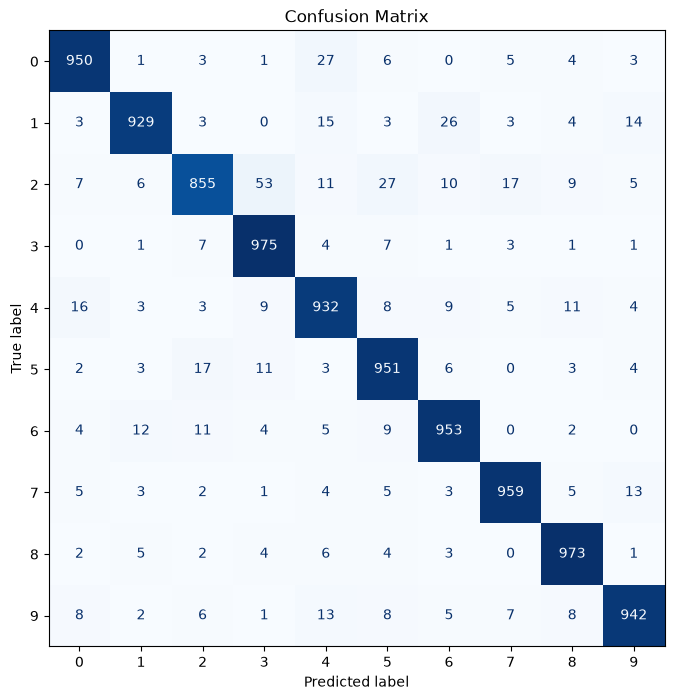

In [14]:

test_loss, test_acc = evaluate(test_loader, model)
print(f"\nTest Accuracy: {test_acc:.2f}%")


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().tolist()

        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()
